In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# Carregamento da imagem em nível de cinza (apenas 1 canal)
img = cv2.imread('gato.jpg', cv2.IMREAD_GRAYSCALE)
print(f"Dimensões da imagem (gato.jpg): {img.shape}")


Dimensões da imagem (gato.jpg): (683, 1024)


In [2]:
# FUNÇÕES DE INTERPOLAÇÃO (IMPLEMENTAÇÃO MANUAL)

def interpolacao_vizinho_mais_proximo(imagem, src_x, src_y):
    H, W = imagem.shape
    x_round = np.round(src_x).astype(np.int32)
    y_round = np.round(src_y).astype(np.int32)
    valido = (x_round >= 0) & (x_round < W) & (y_round >= 0) & (y_round < H)
    saida = np.zeros(src_x.shape, dtype=np.uint8)
    saida[valido] = imagem[y_round[valido], x_round[valido]]
    return saida

def interpolacao_bilinear(imagem, src_x, src_y):
    H, W = imagem.shape
    saida = np.zeros(src_x.shape, dtype=np.float32)
    valido = (src_x >= 0) & (src_x <= W - 1) & (src_y >= 0) & (src_y <= H - 1)
    if not np.any(valido):
        return saida.astype(np.uint8)
    sx = src_x[valido]
    sy = src_y[valido]
    pad_img = np.pad(imagem.astype(np.float32), pad_width=1, mode='edge')
    x1 = np.floor(sx).astype(np.int32)
    y1 = np.floor(sy).astype(np.int32)
    x2 = x1 + 1
    y2 = y1 + 1
    dx = sx - x1
    dy = sy - y1
    q11 = pad_img[y1 + 1, x1 + 1]
    q21 = pad_img[y1 + 1, x2 + 1]
    q12 = pad_img[y2 + 1, x1 + 1]
    q22 = pad_img[y2 + 1, x2 + 1]
    interp = (1.0 - dx) * (1.0 - dy) * q11 + dx * (1.0 - dy) * q21 + (1.0 - dx) * dy * q12 + dx * dy * q22
    saida[valido] = np.clip(interp, 0, 255)
    return saida.astype(np.uint8)

def _pesos_cubicos(d, a=-0.5):
    d1 = d + 1.0
    w_m1 = a * (d1**3) - 5.0 * a * (d1**2) + 8.0 * a * d1 - 4.0 * a
    w_0 = (a + 2.0) * (d**3) - (a + 3.0) * (d**2) + 1.0
    d_1 = 1.0 - d
    w_1 = (a + 2.0) * (d_1**3) - (a + 3.0) * (d_1**2) + 1.0
    d_2 = 2.0 - d
    w_2 = a * (d_2**3) - 5.0 * a * (d_2**2) + 8.0 * a * d_2 - 4.0 * a
    return w_m1, w_0, w_1, w_2

def interpolacao_bicubica(imagem, src_x, src_y, a=-0.5):
    H, W = imagem.shape
    saida = np.zeros(src_x.shape, dtype=np.float32)
    valido = (src_x >= 0) & (src_x <= W - 1) & (src_y >= 0) & (src_y <= H - 1)
    if not np.any(valido):
        return saida.astype(np.uint8)
    sx = src_x[valido]
    sy = src_y[valido]
    pad_img = np.pad(imagem.astype(np.float32), pad_width=2, mode='edge')
    xf = np.floor(sx).astype(np.int32)
    yf = np.floor(sy).astype(np.int32)
    dx = sx - xf
    dy = sy - yf
    wx = _pesos_cubicos(dx, a)
    wy = _pesos_cubicos(dy, a)
    xf_p = xf + 2
    yf_p = yf + 2
    accum = np.zeros(sx.shape, dtype=np.float32)
    for m, w_ym in zip(range(-1, 3), wy):
        ym = yf_p + m
        row_accum = np.zeros(sx.shape, dtype=np.float32)
        for k, w_xk in zip(range(-1, 3), wx):
            xk = xf_p + k
            row_accum += pad_img[ym, xk] * w_xk
        accum += row_accum * w_ym
    saida[valido] = np.clip(accum, 0, 255)
    return saida.astype(np.uint8)


In [3]:
# TRANSFORMAÇÕES GEOMÉTRICAS (MAPEAMENTO INVERSO)

def transformar_escala(imagem, sx, sy, metodo):
    H, W = imagem.shape
    new_H = int(round(H * sy))
    new_W = int(round(W * sx))
    y_grid, x_grid = np.indices((new_H, new_W))
    src_x = x_grid / sx
    src_y = y_grid / sy
    if metodo == 'vizinho':
        return interpolacao_vizinho_mais_proximo(imagem, src_x, src_y)
    elif metodo == 'bilinear':
        return interpolacao_bilinear(imagem, src_x, src_y)
    elif metodo == 'bicubica':
        return interpolacao_bicubica(imagem, src_x, src_y)

def transformar_rotacao(imagem, angulo, metodo):
    H, W = imagem.shape
    theta = np.deg2rad(angulo)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    y_grid, x_grid = np.indices((H, W))
    x_shift = x_grid - cx
    y_shift = y_grid - cy
    src_x = x_shift * cos_t + y_shift * sin_t + cx
    src_y = -x_shift * sin_t + y_shift * cos_t + cy
    if metodo == 'vizinho':
        return interpolacao_vizinho_mais_proximo(imagem, src_x, src_y)
    elif metodo == 'bilinear':
        return interpolacao_bilinear(imagem, src_x, src_y)
    elif metodo == 'bicubica':
        return interpolacao_bicubica(imagem, src_x, src_y)

def transformar_cisalhamento(imagem, shx, shy, metodo):
    H, W = imagem.shape
    new_W = int(round(W + abs(shx) * H))
    new_H = int(round(H + abs(shy) * W))
    y_grid, x_grid = np.indices((new_H, new_W))
    det = 1.0 - shx * shy
    offset_x = abs(shx) * H if shx < 0 else 0
    offset_y = abs(shy) * W if shy < 0 else 0
    xp = x_grid - offset_x
    yp = y_grid - offset_y
    src_x = (xp - shx * yp) / det
    src_y = (-shy * xp + yp) / det
    if metodo == 'vizinho':
        return interpolacao_vizinho_mais_proximo(imagem, src_x, src_y)
    elif metodo == 'bilinear':
        return interpolacao_bilinear(imagem, src_x, src_y)
    elif metodo == 'bicubica':
        return interpolacao_bicubica(imagem, src_x, src_y)


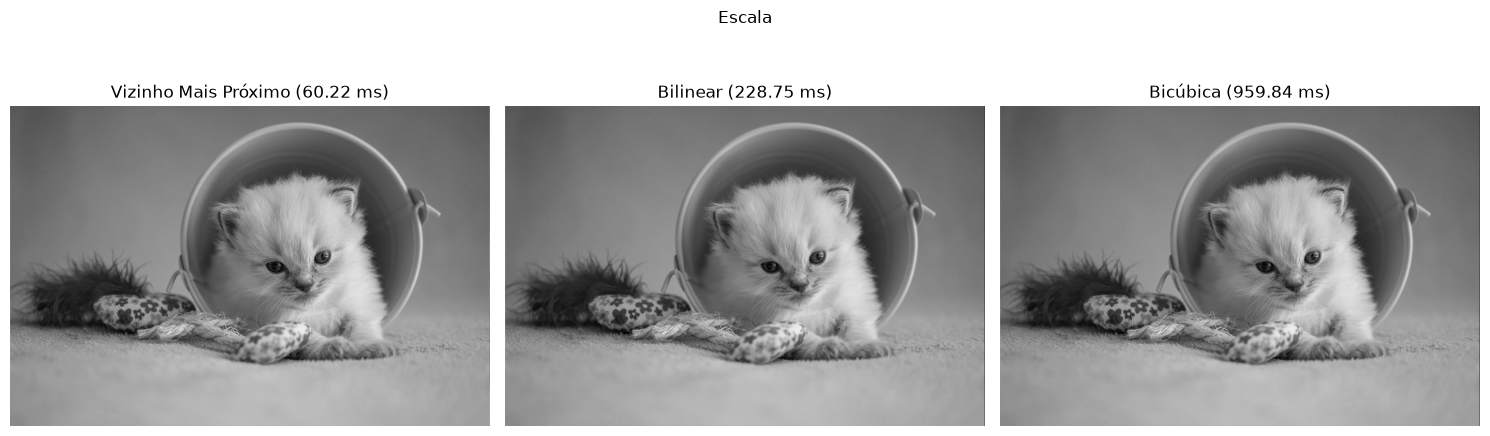

In [4]:
# 1) b) Escala: Aplicação e comparação dos métodos de interpolação
sx, sy = 1.5, 1.5

t0 = time.perf_counter()
escala_vizinho = transformar_escala(img, sx, sy, 'vizinho')
t_esc_viz = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
escala_bilinear = transformar_escala(img, sx, sy, 'bilinear')
t_esc_bil = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
escala_bicubica = transformar_escala(img, sx, sy, 'bicubica')
t_esc_bic = (time.perf_counter() - t0) * 1000

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(escala_vizinho, cmap='gray')
axs[0].set_title(f'Vizinho Mais Próximo ({t_esc_viz:.2f} ms)')
axs[0].axis('off')

axs[1].imshow(escala_bilinear, cmap='gray')
axs[1].set_title(f'Bilinear ({t_esc_bil:.2f} ms)')
axs[1].axis('off')

axs[2].imshow(escala_bicubica, cmap='gray')
axs[2].set_title(f'Bicúbica ({t_esc_bic:.2f} ms)')
axs[2].axis('off')

plt.suptitle('Escala')
plt.tight_layout()
plt.show()


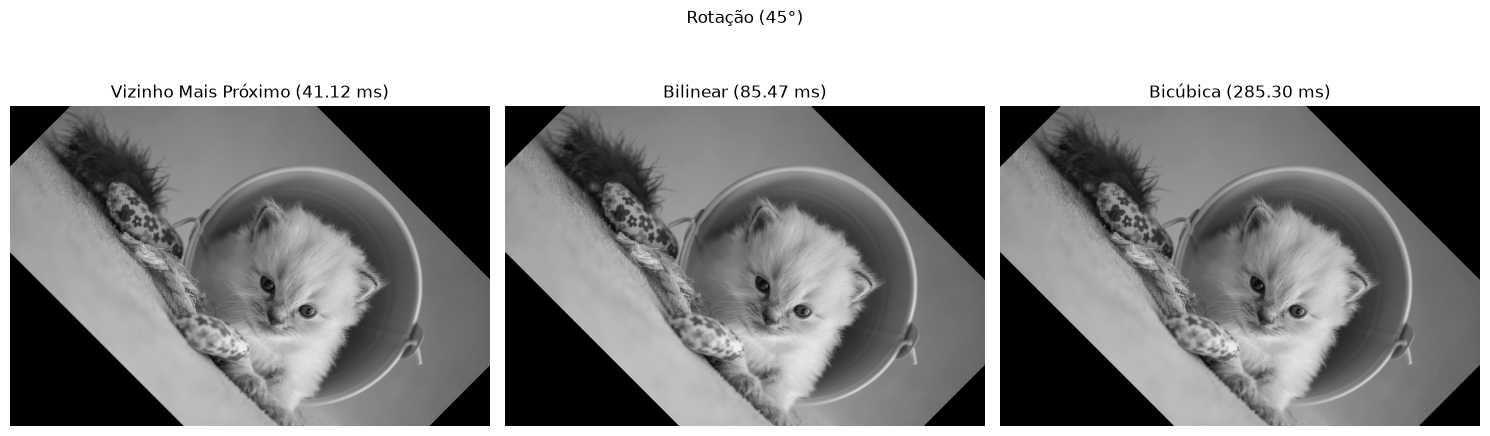

In [5]:
# 1) b) Rotação: Aplicação e comparação dos métodos de interpolação
angulo = 45

t0 = time.perf_counter()
rot_vizinho = transformar_rotacao(img, angulo, 'vizinho')
t_rot_viz = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
rot_bilinear = transformar_rotacao(img, angulo, 'bilinear')
t_rot_bil = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
rot_bicubica = transformar_rotacao(img, angulo, 'bicubica')
t_rot_bic = (time.perf_counter() - t0) * 1000

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(rot_vizinho, cmap='gray')
axs[0].set_title(f'Vizinho Mais Próximo ({t_rot_viz:.2f} ms)')
axs[0].axis('off')

axs[1].imshow(rot_bilinear, cmap='gray')
axs[1].set_title(f'Bilinear ({t_rot_bil:.2f} ms)')
axs[1].axis('off')

axs[2].imshow(rot_bicubica, cmap='gray')
axs[2].set_title(f'Bicúbica ({t_rot_bic:.2f} ms)')
axs[2].axis('off')

plt.suptitle('Rotação (45°)')
plt.tight_layout()
plt.show()


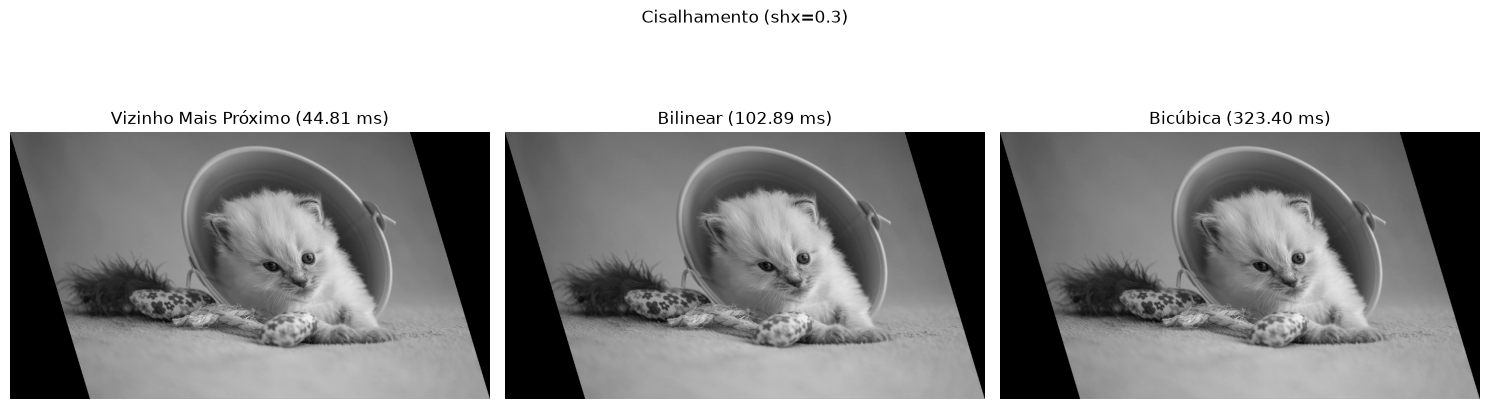

In [6]:
# 1) b) Cisalhamento (Shear): Aplicação e comparação dos métodos de interpolação
shx, shy = 0.3, 0.0

t0 = time.perf_counter()
shear_vizinho = transformar_cisalhamento(img, shx, shy, 'vizinho')
t_sh_viz = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
shear_bilinear = transformar_cisalhamento(img, shx, shy, 'bilinear')
t_sh_bil = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
shear_bicubica = transformar_cisalhamento(img, shx, shy, 'bicubica')
t_sh_bic = (time.perf_counter() - t0) * 1000

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(shear_vizinho, cmap='gray')
axs[0].set_title(f'Vizinho Mais Próximo ({t_sh_viz:.2f} ms)')
axs[0].axis('off')

axs[1].imshow(shear_bilinear, cmap='gray')
axs[1].set_title(f'Bilinear ({t_sh_bil:.2f} ms)')
axs[1].axis('off')

axs[2].imshow(shear_bicubica, cmap='gray')
axs[2].set_title(f'Bicúbica ({t_sh_bic:.2f} ms)')
axs[2].axis('off')

plt.suptitle('Cisalhamento (shx=0.3)')
plt.tight_layout()
plt.show()


In [7]:
# Comparação de Desempenho Computacional (Tempo de Execução em ms)
print(f"{'Transformação':<15} | {'Vizinho (ms)':<15} | {'Bilinear (ms)':<15} | {'Bicúbica (ms)':<15}")
print('-' * 65)
print(f"{'Escala':<15} | {t_esc_viz:<15.2f} | {t_esc_bil:<15.2f} | {t_esc_bic:<15.2f}")
print(f"{'Rotação':<15} | {t_rot_viz:<15.2f} | {t_rot_bil:<15.2f} | {t_rot_bic:<15.2f}")
print(f"{'Cisalhamento':<15} | {t_sh_viz:<15.2f} | {t_sh_bil:<15.2f} | {t_sh_bic:<15.2f}")


Transformação   | Vizinho (ms)    | Bilinear (ms)   | Bicúbica (ms)  
-----------------------------------------------------------------
Escala          | 60.22           | 228.75          | 959.84         
Rotação         | 41.12           | 85.47           | 285.30         
Cisalhamento    | 44.81           | 102.89          | 323.40         


### Comparação dos Métodos de Interpolação (Qualidade e Desempenho)

**Qualidade da Imagem:**
- **Vizinho Mais Próximo:** Gera forte pixelização em escala e serrilhamento acentuado em rotação e cisalhamento, com perda de detalhes finos.
- **Bilinear:** Elimina a pixelização e suaviza arestas ponderando 4 vizinhos, mas introduz um leve embaçamento (blur) em detalhes finos.
- **Bicúbica:** Apresenta a melhor qualidade visual em todas as transformações, preservando bordas nítidas e texturas sem o desfoque da bilinear e sem o serrilhamento do vizinho mais próximo.

**Desempenho Computacional:**
- **Vizinho Mais Próximo (O(1)):** Mais rápido e simples (~15 a 43 ms nos testes), exigindo apenas arredondamento e 1 leitura por pixel.
- **Bilinear (O(4)):** Custo intermediário (~60 a 208 ms, 3x a 5x mais lenta que o vizinho), ideal para aplicações em tempo real.
- **Bicúbica (O(16)):** Mais lenta e custosa (~273 a 991 ms, 15x a 20x mais lenta que o vizinho), justificada quando a qualidade e nitidez são prioritárias.